In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
forcing_data_path = '/Users/jbec0008/hackdata/'
projections_data_path = '/Users/jbec0008/hackdata/'

In [2]:
# Example experiment and corresponding ocean forcing names this can be drawn from the INFOS Dataframe
experiment = 'expAE02'
climate_model = 'ccsm4_RCP85'
name = 'ccsm4_RCP85'
model = 'PIK_PISM'

# experiment = 'expAE05'
# climate_model = 'UKESM1-0-LL_SSP585'
# name = 'UKESM1-0-LL_SSP585'

# 1.  Load ice draft 

In [3]:
draft = xr.open_dataset(projections_data_path+"/"+model+"/"+experiment+'_8/base_AIS_'+model+'_'+experiment+'.nc')



/Users/jbec0008/python-virtual-environments/vpyplus/lib/python3.9/site-packages/xarray/coding/times.py:710: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


# 2. Load floating mask

In [4]:
mask_floating='sftflf_AIS_'+model+'_'+experiment+'.nc'

# FIXME: we might need to remove the 8 here
d = xr.open_dataset(projections_data_path+"/"+model+"/"+experiment+'_8/'+mask_floating)

time_model = np.empty(len(d['time'].values))
for i in range(len(d['time'].values)):
    time_model[i] = (int(d.sftflf['time'].values[i].strftime().split('-')[0]))

/Users/jbec0008/python-virtual-environments/vpyplus/lib/python3.9/site-packages/xarray/coding/times.py:710: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


# 3. Get ocean forcing data

In [27]:
tf = xr.open_dataset(
    forcing_data_path+name+"_thermal_forcing_8km_x_60m.nc")



In [6]:
# Get the time from the forcing

time_forcing = np.empty(len(tf['time'].values))
for i in range(len(tf['time'].values)):
    time_forcing[i] = (int(tf['time'].values[i].strftime().split('-')[0]))


# 4. create empty nc files

In [42]:
### Creating a nc data set with the temp of the bin

# create emty nc file for Tbin at shelf, d_calc will have T d_bin will have bin number

d_calc =d.copy()
d_calc.attrs ={}
variable_name = 'thermalforcing_bin'
varname_old = 'sftflf'
d_calc =d_calc.rename({varname_old:variable_name })

d_calc.thermalforcing_bin.values = np.zeros((d_calc.thermalforcing_bin.shape))
d_bin =d.copy()
d_bin.attrs={}
d_bin =d_bin.rename({varname_old:'bin_number' })
d_bin.bin_number.values = np.zeros((d_calc.thermalforcing_bin.shape))



In [43]:
zbnd = tf.get('z_bnds').values[0,:]
for timei,time  in enumerate(time_model[time_model<=2300]):
    ##select time from forcing data set (it is shifted)
   
    
    # get mask of shelf
    m_in=d.isel(time =timei).sftflf.values

    m = m_in >0.5 #takes cells that are mostly floating

    shelf_draft =draft.isel(time =timei).base.values
    shelf_draft[~m]=100
     # This will be the relevant thermal forcing bin number

    shelf_draft_bin = np.empty(shelf_draft.shape)
    shelf_draft_bin[:] = np.nan

    # This will be the relevant thermal forcing
    shelf_draft_bin_temp = np.empty(shelf_draft.shape)
    shelf_draft_bin_temp[:] = np.nan
    

    # create a mask of the depth indices of the shelf draft
    for i,zbnd_i in enumerate(zbnd):
        zmax = zbnd_i[0]
        zmin = zbnd_i[-1]
        ind_mask = np.nonzero(np.logical_and(shelf_draft<zmax, shelf_draft>=zmin))
        shelf_draft_bin[ind_mask] = i 
    #get bin number    

    d_bin.isel(time =timei).bin_number.values[:] =shelf_draft_bin.copy()
    yr =int(time_model[timei])
    print(yr)
    tf_time = tf.loc[{'time': slice(str(yr)+'-01',str(yr)+'-12')}].thermal_forcing.values[0,]
    
    for i,z in enumerate(tf.thermal_forcing.z.values):
        maski = shelf_draft_bin==i
        shelf_draft_bin_temp[maski] = tf_time[i,maski]
    # get thermal focing in
    d_calc.isel(time =timei).thermalforcing_bin.values[:] =shelf_draft_bin_temp.copy()
 
    break

2016


In [24]:
d_calc.to_netcdf(projections_data_path+"/"+model+"/"+experiment+'_8/shelf_thermalforcingBin_AIS_'+model+'_'+experiment+'.nc')
d_bin.to_netcdf(projections_data_path+"/"+model+"/"+experiment+'_8/shelf_numberBin_AIS_'+model+'_'+experiment+'.nc')


/Users/jbec0008/python-virtual-environments/vpyplus/lib/python3.9/site-packages/xarray/core/indexing.py:524: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(array[self.key], dtype=None)
/Users/jbec0008/python-virtual-environments/vpyplus/lib/python3.9/site-packages/xarray/core/indexing.py:524: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(array[self.key], dtype=None)


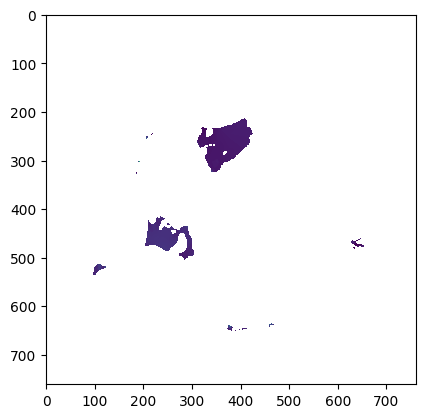

In [31]:
plt.imshow(d_bin.bin_number.values[0,])


In [21]:
d_bin.isel(time =timei)

<xarray.Dataset>
Dimensions:     (x: 761, y: 761, nv: 2)
Coordinates:
  * x           (x) float32 -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
  * y           (y) float32 -3.04e+06 -3.032e+06 ... 3.032e+06 3.04e+06
    time        object 2300-01-01 00:00:00
Dimensions without coordinates: nv
Data variables:
    mapping     float64 0.0
    bin_number  (y, x) float64 nan nan nan nan nan nan ... nan nan nan nan nan
    time_bnds   (nv) object 2298-09-14 00:00:00 2299-09-14 00:00:00

In [ ]:
d_calc.thermalforcing_bin.values = np.zeros((d_calc.thermalforcing_bin.shape))


In [44]:
np.unique(d_bin.bin_number.values[0,])


array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 29., nan])

In [33]:
np.unique(shelf_draft_bin)

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 29., nan])

In [45]:
np.unique(d_calc.thermalforcing_bin.values[0,])


array([0.00000000e+00, 2.88373558e-04, 1.78353873e-03, ...,
       3.56642222e+00, 3.56750679e+00,            nan])